In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import numpy as np

In [ ]:
TEXT2VQL_ROOT = os.path.abspath(os.getcwd())

while True:
    if os.path.basename(TEXT2VQL_ROOT) == "Text2VQL":
        break
    new = os.path.dirname(TEXT2VQL_ROOT)
    if new == TEXT2VQL_ROOT:
        raise FileNotFoundError("Could not find a parent directory named 'Text2VQL'.")
    TEXT2VQL_ROOT = new

# Process data

In [3]:
def test_dataset():    
    data = []

    llms = ["LLM_A", "LLM_B"]
    finetune_flags = [False, True]
    cases = list(range(1, 20))
    domains = ["text2vql", "railway", "dlt", "cps"]
    langs = ["java", "vql"]

    np.random.seed(42)
    for llm in llms:
        for caseid in cases:
            for finetune in finetune_flags:
                for lang in langs:
                    for shotid in range(1, 6):
                        syntax_ok = np.random.choice([True, False], p=[0.8, 0.2])
                        semantics_ok = np.random.choice([True, False], p=[0.7, 0.3]) if syntax_ok else False
                        data.append({
                            "llm": llm,
                            "finetune": finetune,
                            "caseid": caseid,
                            "domain": np.random.choice(domains),
                            "lang": lang,
                            "shotid": shotid,
                            "query": f"SELECT * FROM table_{caseid}_shot_{shotid};",
                            "syntax": syntax_ok,
                            "diagnostics": None,
                            "semantics": semantics_ok,
                            "idicator": None
                        })

    return pd.DataFrame(data)

In [ ]:
def classify(row):
    if not row["syntax"]:
        return "Syntax Error"
    elif not row["semantics"]:
        return "Semantic Error"
    else:
        return "Correct"

In [ ]:
with sqlite3.connect(os.path.join(TEXT2VQL_ROOT,'finetuning/evaluation-sample.db')) as conn:
    df = pd.read_sql_query("SELECT * FROM evaluation", conn)
    df["category"] = df.apply(classify, axis=1)

In [5]:
df = test_dataset()
df["category"] = df.apply(classify, axis=1)

## Correctness

In [14]:
results = (
    df.groupby(["llm", "finetune", "caseid", "category", "lang"])
    .size()
    .reset_index(name="count")
)
results["finetune"] = results["finetune"].map({True: "Finetuned", False: "In context"})
totals = results.groupby(["llm", "finetune"])["count"].transform("sum")
results["x_label"] = results["caseid"].astype(str) + " - " + results["finetune"]

In [34]:
def plot_llm_subplot(ax, data, llm, language, legend=False, llmlabels=["In context", "Finetuned"], colors = {"Syntax Error": "#e74c3c", "Semantic Error": "#f39c12", "Correct": "#27ae60"}):
    subset = data[(data["llm"] == llm) & (data["lang"] == language)]

    caseids = sorted(subset["caseid"].unique())
    x = np.arange(len(caseids))
    width = 0.35

    handles = []
    labels = []

    for i, finetune_label in enumerate(llmlabels):
        sub = subset[subset["finetune"] == finetune_label]
        pivot = sub.pivot(index="caseid", columns="category", values="count").fillna(0)
        bottoms = np.zeros(len(pivot))
        positions = x + (i - 0.5) * width

        for cat in ["Syntax Error", "Semantic Error", "Correct"]:
            values = pivot[cat].values if cat in pivot.columns else np.zeros(len(pivot))
            label = cat if cat not in labels else None
            bar = ax.bar(
                positions,
                values,
                width=width,
                bottom=bottoms,
                color=colors[cat],
                label=label
            )
            bottoms += values

            if cat not in labels:
                handles.append(bar[0])
                labels.append(cat)

    ax.set_title(f"LLM: {llm}", fontsize=14)
    ax.set_xlim(x[0] - width - 0.05, x[-1] + width + 0.05)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Case {cid}" for cid in caseids])
    ax.set_xlabel("Test Case")
    ax.set_ylabel("Number of Queries")
    if legend:
        ax.legend(title="Correctness", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add labels for Base / Finetuned
    for i, cid in enumerate(caseids):
        ax.text(x[i] - width/2, 0, "Base", ha="center", va="top", fontsize=9, color="gray")
        ax.text(x[i] + width/2, 0, "Finetuned", ha="center", va="top", fontsize=9, color="gray")

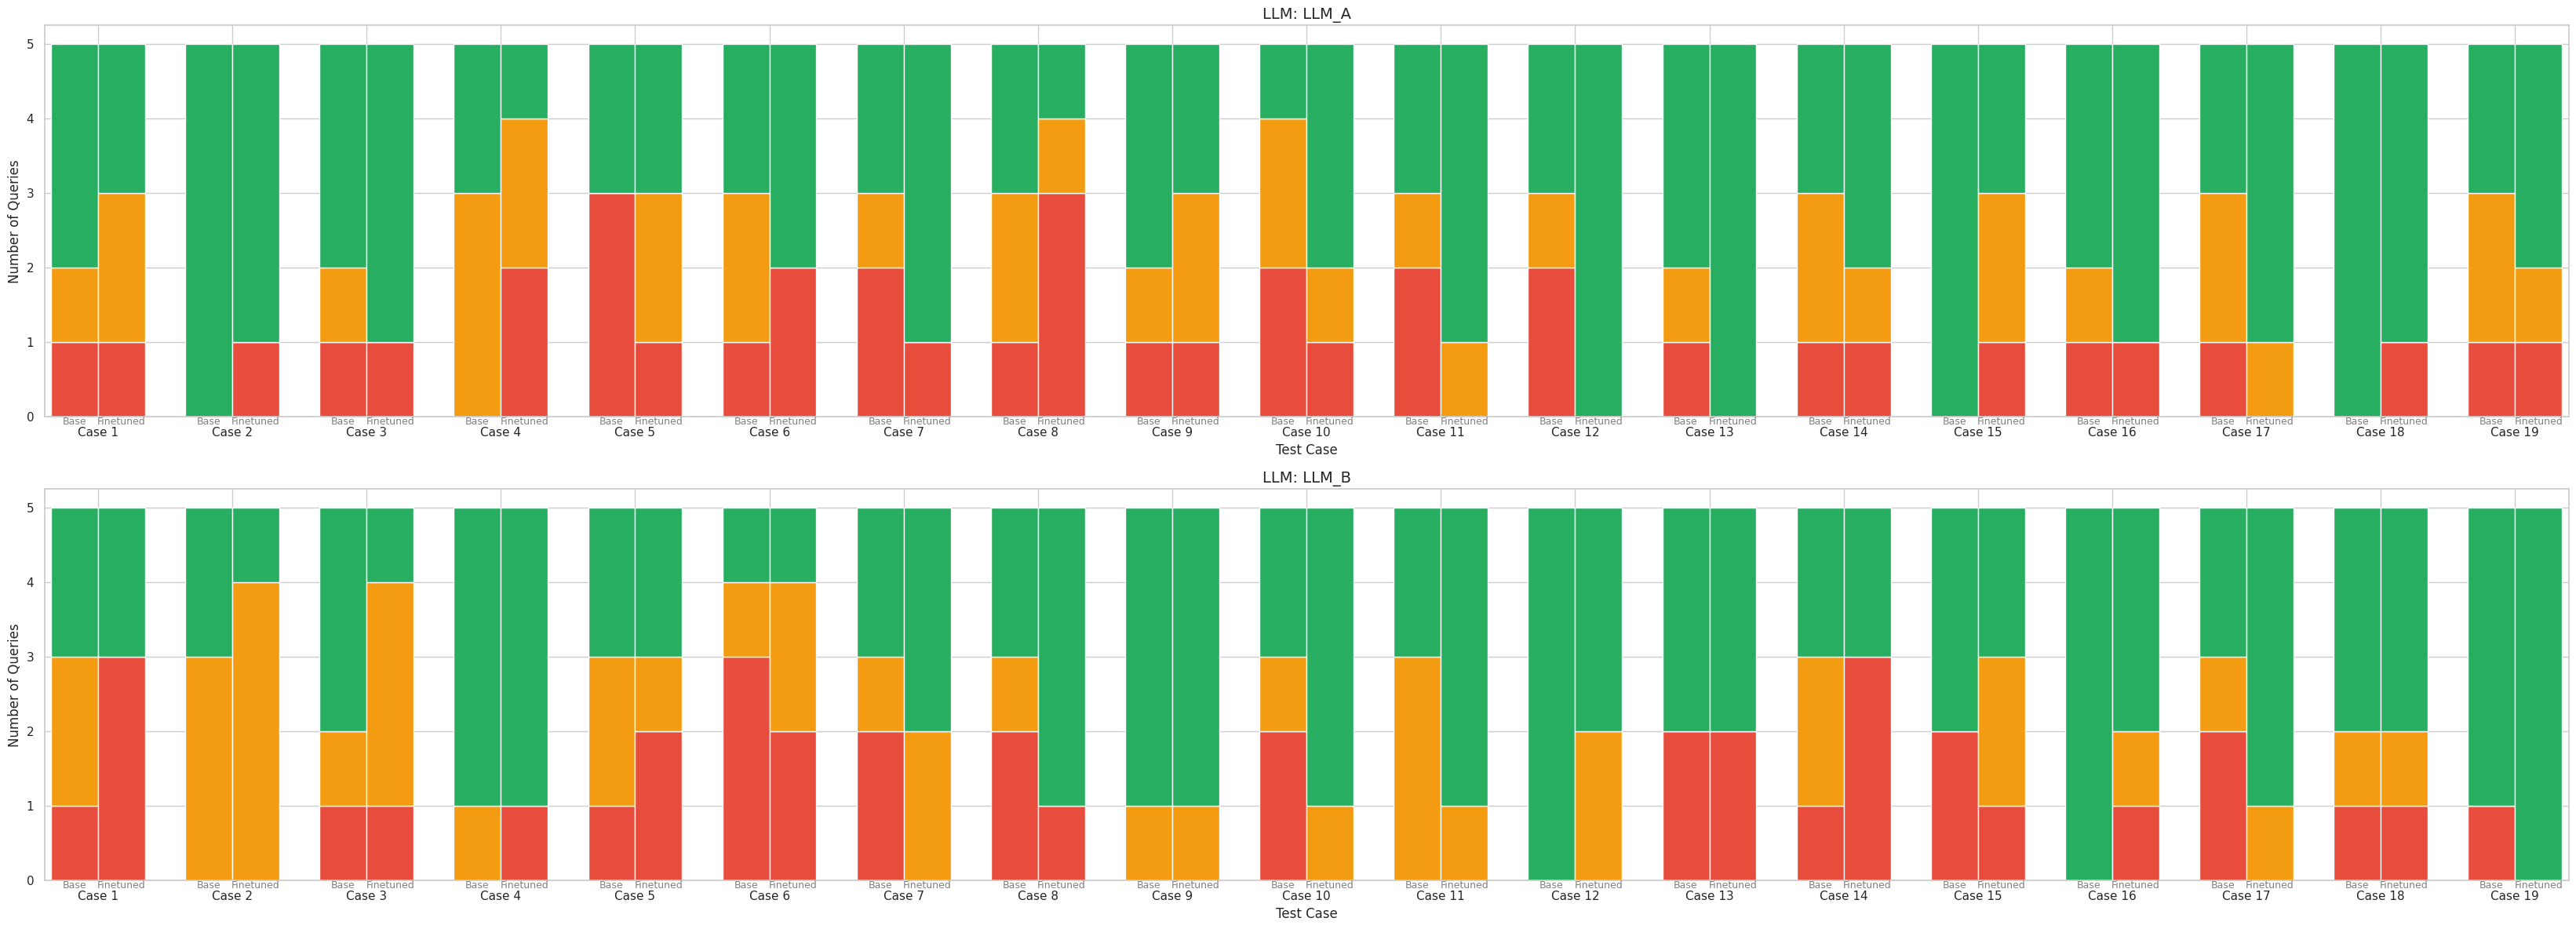

In [ ]:
sns.set(style="whitegrid", palette="muted")
llms = results["llm"].unique()
n_llms = len(llms)
cases = results["caseid"].unique()
n_cases = len(cases)

fig, axes = plt.subplots(n_llms, 1, figsize=(2 * n_cases - 5, 6 * n_llms), sharey=True)

if n_llms == 1:
    axes = [axes]

for ax, llm in zip(axes, llms):
    plot_llm_subplot(ax, results, llm, "vql")

plt.tight_layout()
plt.savefig("llm_results.pdf") 
plt.show()